# Objectif du notebook 

Date de création : 23/01/2026

Analyse des RTFs pour des séquences d'émissions tractée. 

In [59]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sp 
from datetime import datetime, timedelta

# import gc

In [60]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [61]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color 
from propa.rtf.rtf_utils import D_hermitian_angle_fast

from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    FiberscopeManager,
    BandFilter,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import get_dists_2 

In [62]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

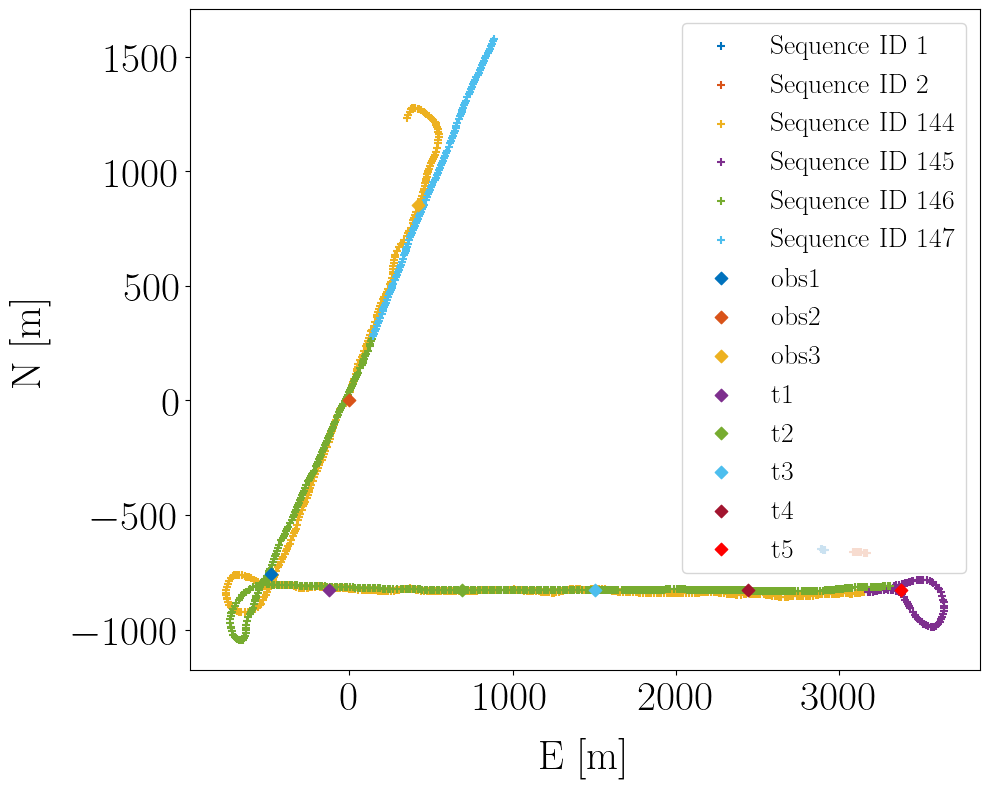

In [63]:
# Tracer des positions d'émission et des positions des OBS sur une carte
df_arr_plot = df_arr.loc[df_arr["src_pos_status"] == "trailed"]
sel_sequence_id_to_analyse = df_arr_plot["sequence_id"].unique()

seq_mean_fscore = []

# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score_obs1"].iloc[0]
        + df_sequence["f_score_obs2"].iloc[0]
        + df_sequence["f_score_obs3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)

    # Série de positions successives
    plt.scatter(
        df_sequence["emission_interp_e_gps"],
        df_sequence["emission_interp_n_gps"],
        marker="+",
        color=color(i),
        label=f"Sequence ID {seq_id}",
    )


plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=10,
        color=color(ik),
        s=40,
    )


plt.legend()

In [64]:
for i, seq_id in enumerate(sel_sequence_id_to_analyse): 
    print(f'ID {seq_id} -> {seq_mean_fscore[i]}')
# print(sel_sequence_id_to_analyse)
# print(seq_mean_fscore)

ID 1 -> 0.6288472372739631
ID 2 -> 0.5605566389365716
ID 144 -> 0.736790982387407
ID 145 -> 0.7040957395160162
ID 146 -> 0.7089368954104701
ID 147 -> 0.7692260212048029


# Étude séquence 144 vs 147

In [65]:
seq_id = [144, 145]  # , 134, 135, 136, 143]
df_seq = df_arr.loc[df_arr["sequence_id"].isin(seq_id)]

In [66]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = True
process_pulse_one_by_one = True

fsm = FiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=3,
    process_pulse_one_by_one=process_pulse_one_by_one,
)

In [68]:
# Analyse rtf variations
fmin = 600
fmax = 800

# Trailed sequences
# seq_ref =
seq_ref = 118       # OBS 2 : 116, 117, 118,
# seq_ref = 127
# seq_ref = 151
seq_id = 144 

In [69]:
theta_distances, spatial_distances, xr_seq_ref, df_seq_ref, xr_seq, df_seq = (
    get_dists_2(fsm=fsm, df_arr=df_arr, seq_id_ref=seq_ref, seq_id=seq_id, fmin=fmin, fmax=fmax)
)

pulse_id = xr_seq.pulse_id.values
pulse_dt = df_seq["emission_datetime"]
pulse_id_ref = xr_seq_ref.pulse_id.values
pulse_dt_ref = df_seq_ref["emission_datetime"]

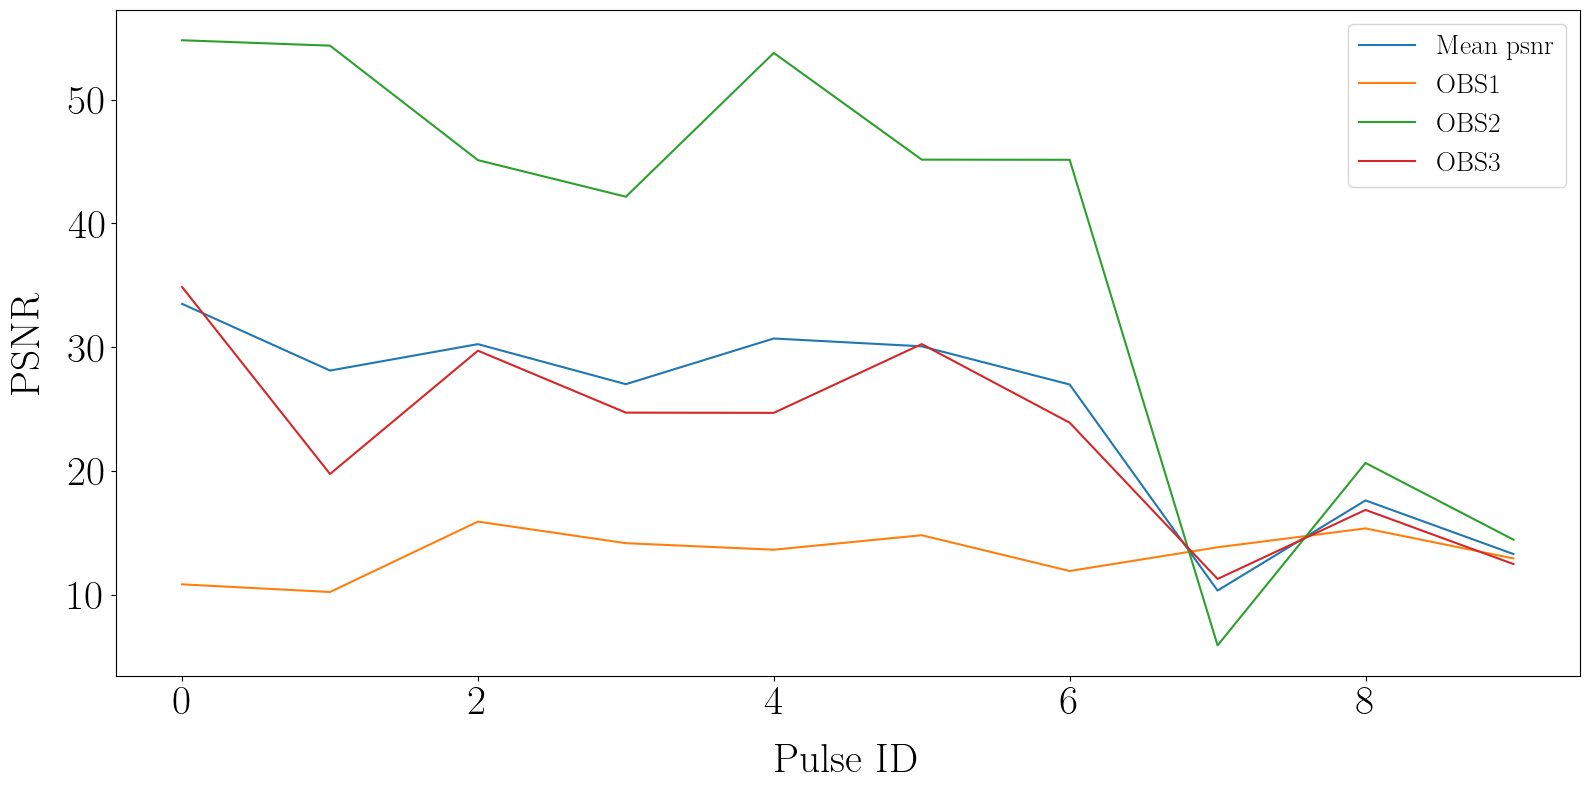

In [81]:
all_psnr = np.array([df_seq_ref[f"psnr_obs{obs_id}"] for obs_id in [1, 2, 3]])
mean_psnr = np.mean(all_psnr, axis=0)
plt.figure()
plt.plot(pulse_id_ref, mean_psnr, label=f"Mean psnr")
for obs_id in [1, 2, 3]:
    # plt.plot(pulse_id_ref, df_seq_ref[f"f_score OBS{obs_id}"], label=f"OBS{obs_id}")
    plt.plot(pulse_id_ref, df_seq_ref[f"psnr_obs{obs_id}"], label=f"OBS{obs_id}")
    

plt.xlabel("Pulse ID")
# plt.ylabel("f_score")
plt.ylabel("PSNR")
plt.legend()

In [71]:
# Normalize theta dist to 1
theta_distances = (90 - np.array(theta_distances)) / 90
# # Normalize each columns to sum to 1 (presence probability)
# theta_distances = theta_distances / np.sum(theta_distances, axis=1)[:, np.newaxis]

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_4588\1715450671.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


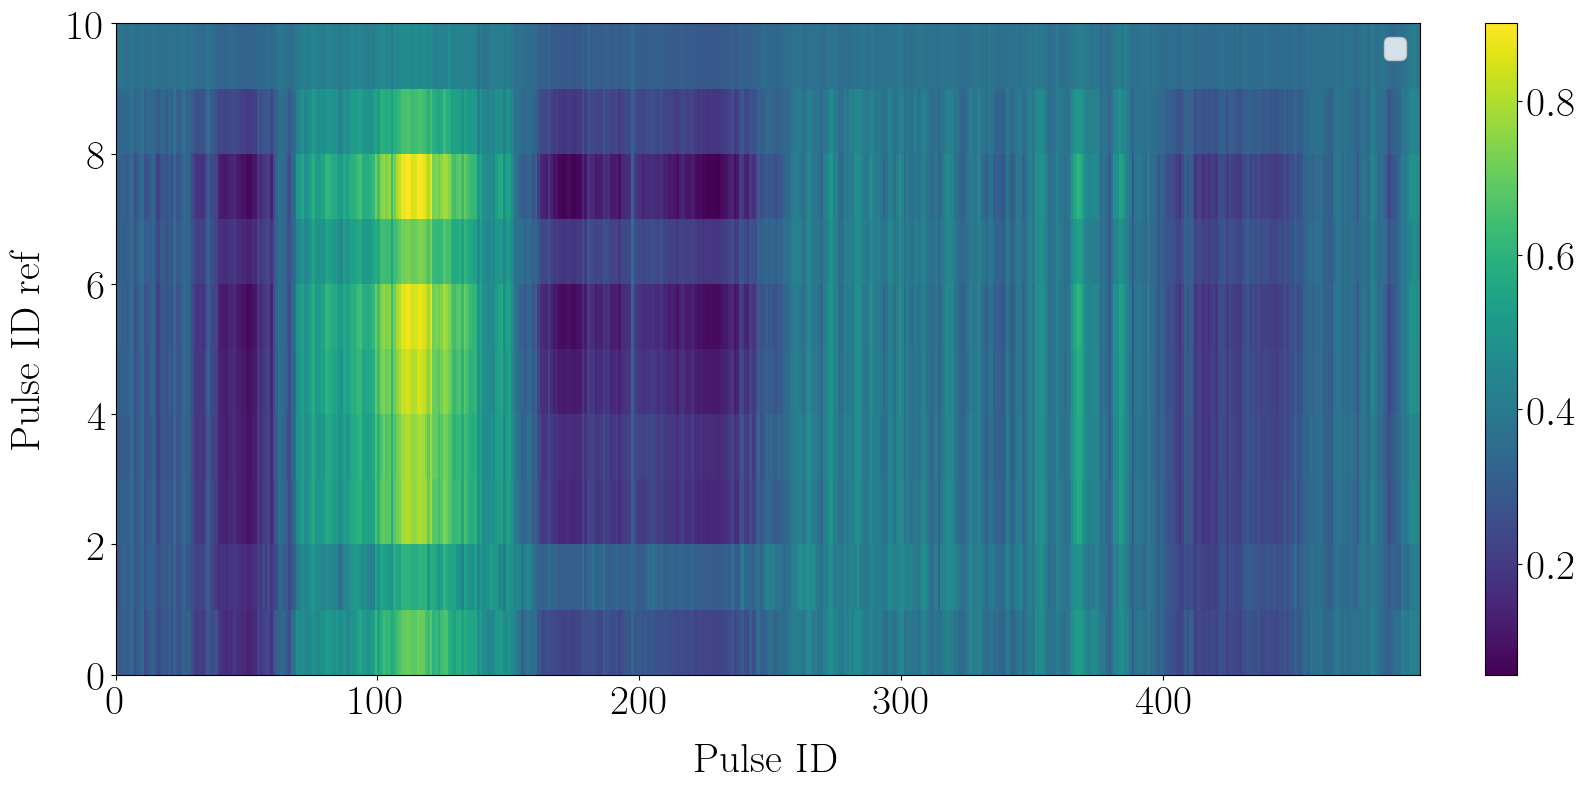

In [72]:
plt.figure()
# plt.title(f"Sequence ID {seq_id} (trailed)")
plt.pcolormesh(theta_distances.T)
plt.colorbar()
plt.xlabel('Pulse ID')
plt.ylabel("Pulse ID ref")
# plt.xlabel("Temps UTC")
# plt.ylabel(r"$\theta$ [°]")

plt.legend()

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_4588\2720639737.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


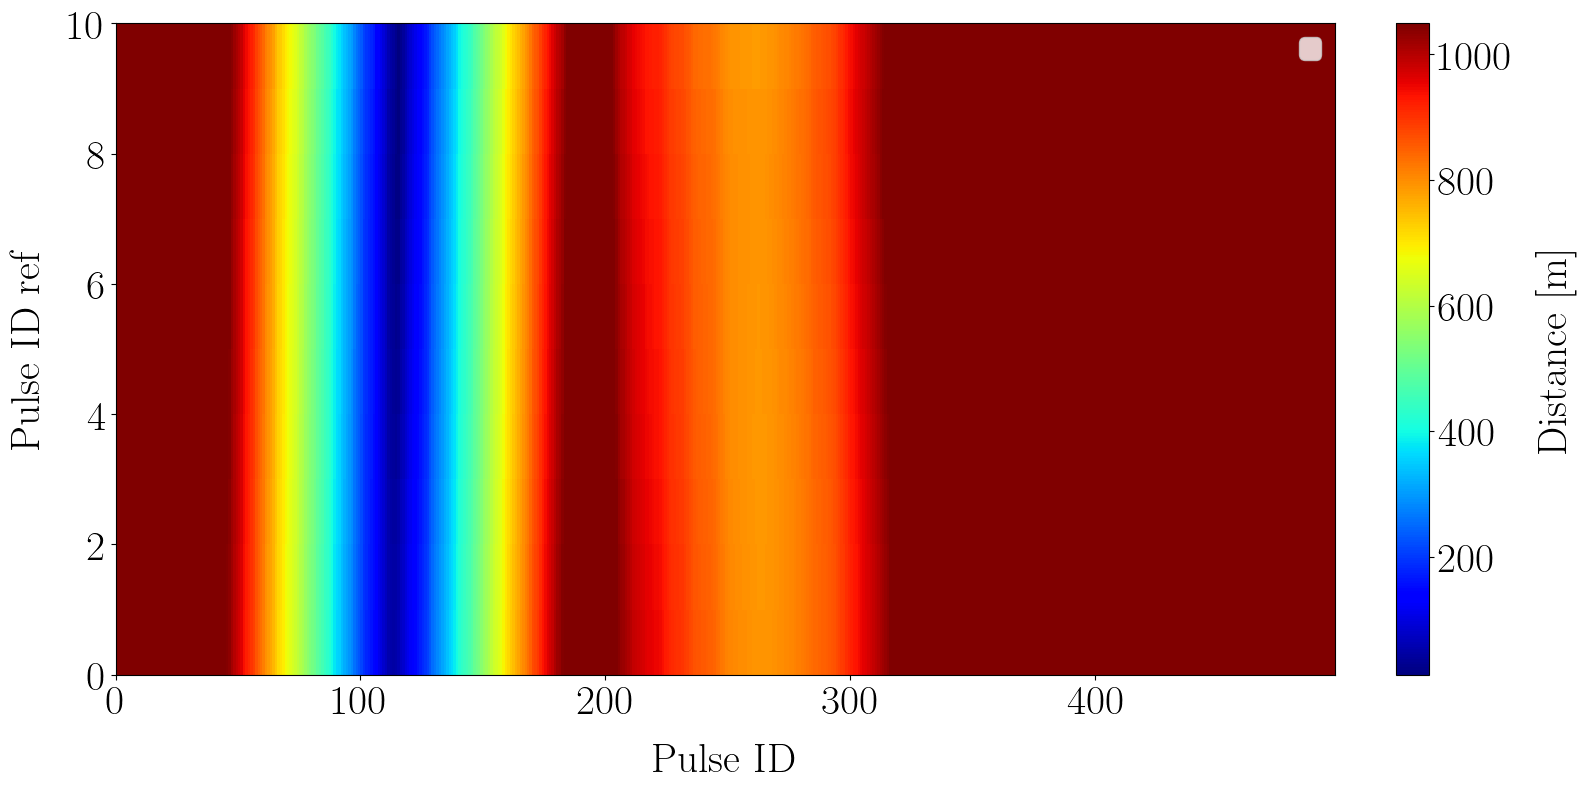

In [73]:
plt.figure()
plt.pcolormesh(
    spatial_distances.T,
    vmin=np.percentile(spatial_distances, 0),
    vmax=np.percentile(spatial_distances, 50),
    cmap="jet"
)
plt.colorbar(label="Distance [m]")
plt.xlabel("Pulse ID")
plt.ylabel("Pulse ID ref")
plt.legend()

In [74]:
# Select a single pulse as ref (for 2 trailed sequences)
spatial_dist_obs = spatial_distances[:, 5]
# theta_dist_obs = theta_distances[:, 5]

# Sum over all pulse (1 trailed vs 1 fixed)
# spatial_dist_obs = spatial_distances[:, 5]
theta_dist_obs = np.mean(theta_distances, axis=1)

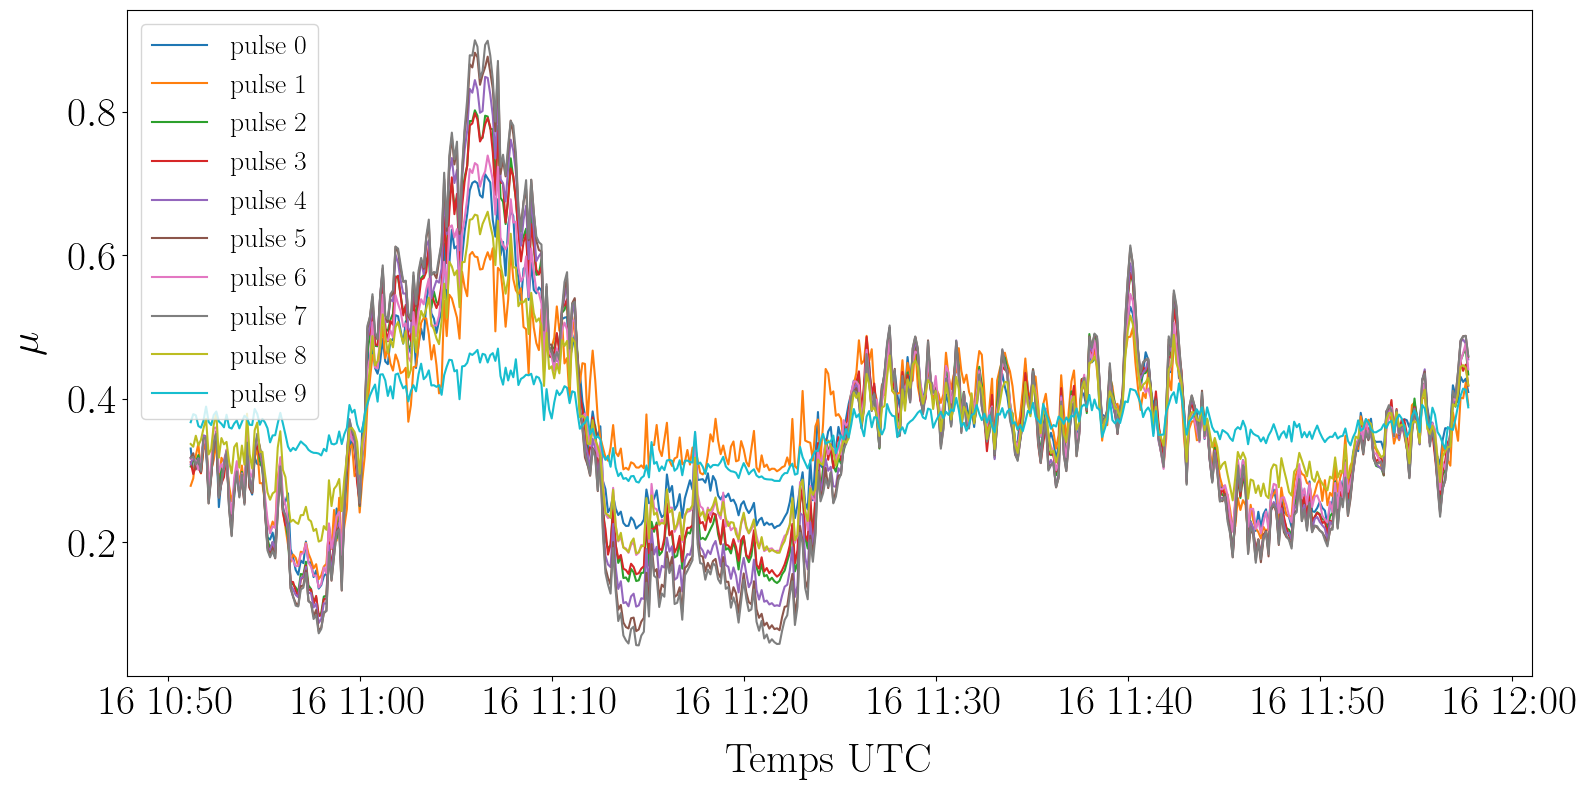

In [75]:
plt.figure()
for i in range(theta_distances.shape[1]):
    plt.plot(pulse_dt, theta_distances[:, i], label=f"pulse {i}")
plt.xlabel("Temps UTC")
plt.ylabel(r"$\mu$")
plt.legend()

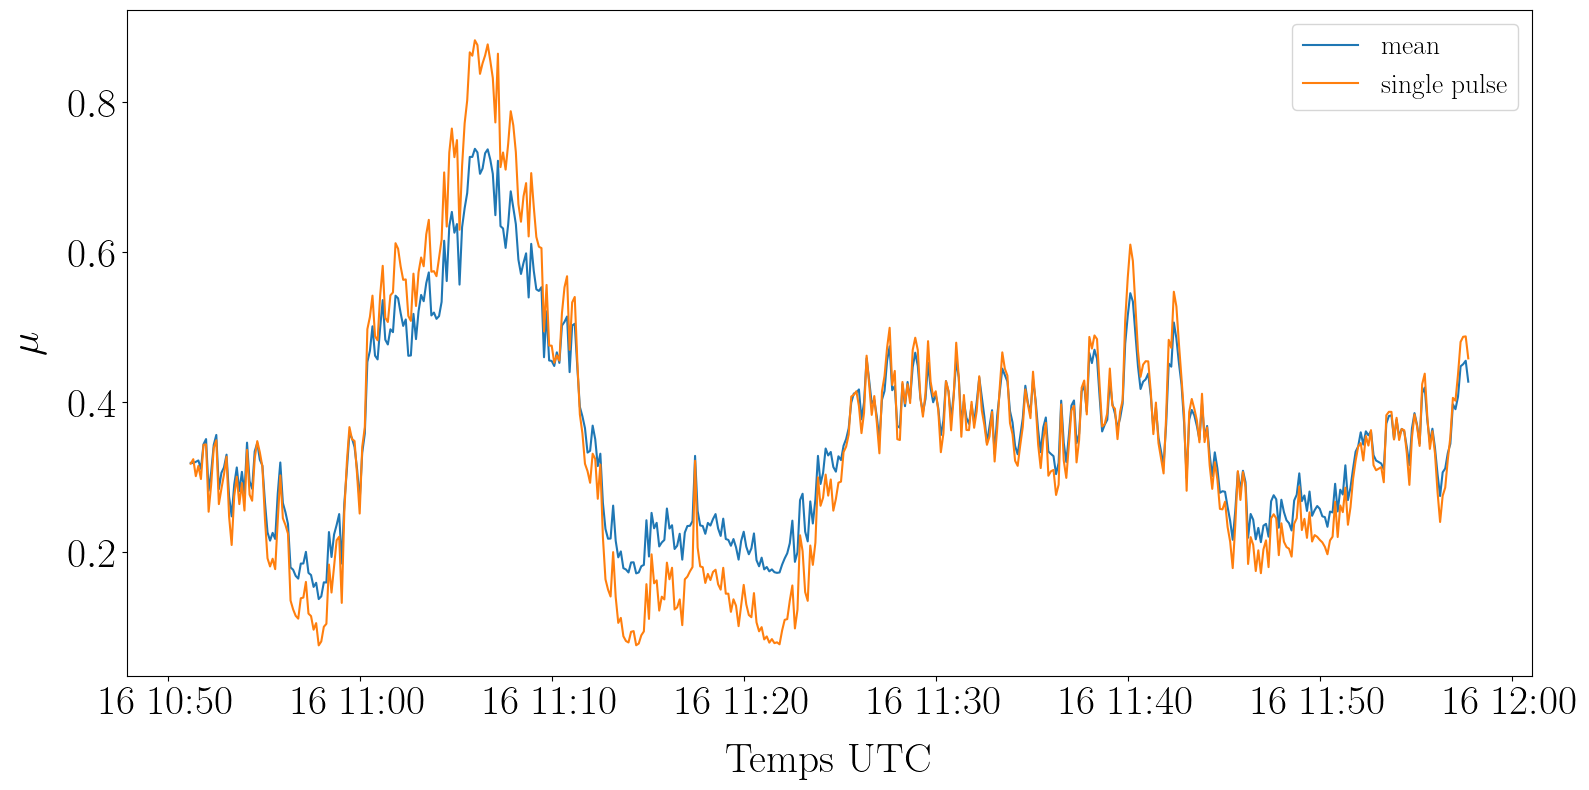

In [76]:
plt.figure()
# plt.title(f"Sequence ID {seq_id} (trailed)")

plt.plot(pulse_dt, theta_dist_obs, label="mean")
plt.plot(pulse_dt, theta_distances[:, 5], label="single pulse")

plt.xlabel("Temps UTC")
plt.ylabel(r"$\mu$")

plt.legend()

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_4588\3064769271.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


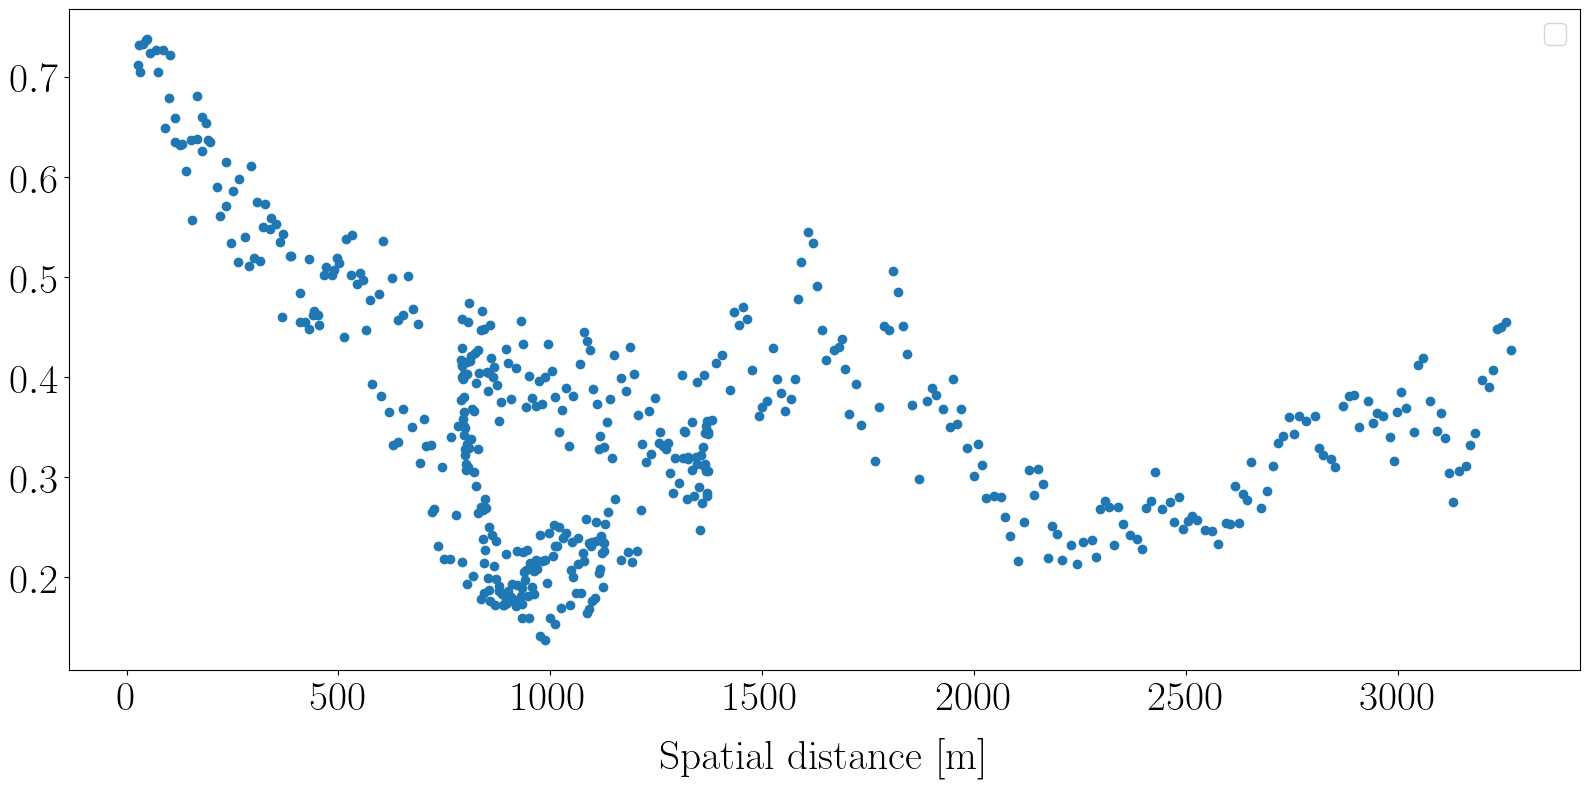

In [77]:
# # Sort by increasing distance
plt.figure()
# plt.title(f"Sequence ID {seq_id} (trailed)")

dist_to_ref_argsort = np.argsort(spatial_dist_obs)
sorted_spatial_dist = spatial_dist_obs[dist_to_ref_argsort]
sorted_theta_dist = theta_dist_obs[dist_to_ref_argsort]

plt.scatter(
    sorted_spatial_dist,
    sorted_theta_dist,
    # label=f"Sequence ID {seq_refs[i]} (OBS{i+1})",
)
plt.xlabel('Spatial distance [m]')
# plt.ylabel(r"$\theta$ [°]")
plt.legend()